# Cascaded Tank Benchmark Code

In [2]:
from time import time
import casadi as ca
import numpy as np
from casadi import sin, cos, pi
import matplotlib.pyplot as plt

In [65]:
# Function for advancing simulation 
def shift_timestep(step_horizon, t0, state_init, u, f):
    f_value = f(state_init, u[:, 0])
    next_state = ca.DM.full(state_init + (step_horizon * f_value))

    t0 = t0 + step_horizon
    u0 = ca.horzcat(
        u[:, 1:],
        ca.reshape(u[:, -1], -1, 1)
    )

    return t0, next_state, u0

# Function for data conversion
def DM2Arr(dm):
    return np.array(dm.full())

# Function for varying the reference with time
def reference_trajectory(t, sim_time, x1_target, x2_target, change=True):
    
    if change == True: # basically just means a changing ref
        if 0 <= t < sim_time/4:
            return x1_target, x2_target
        elif sim_time/4 <= t < 2*sim_time/4:
            return x1_target - 0.2, x2_target - 0.2
        elif 2*sim_time/4 <= t < 3*sim_time/4:
            return x1_target + 0.1, x2_target + 0.1
        else:
            return x1_target + 0.3, x2_target + 0.3
    else:
        return x1_target, x2_target # const ref


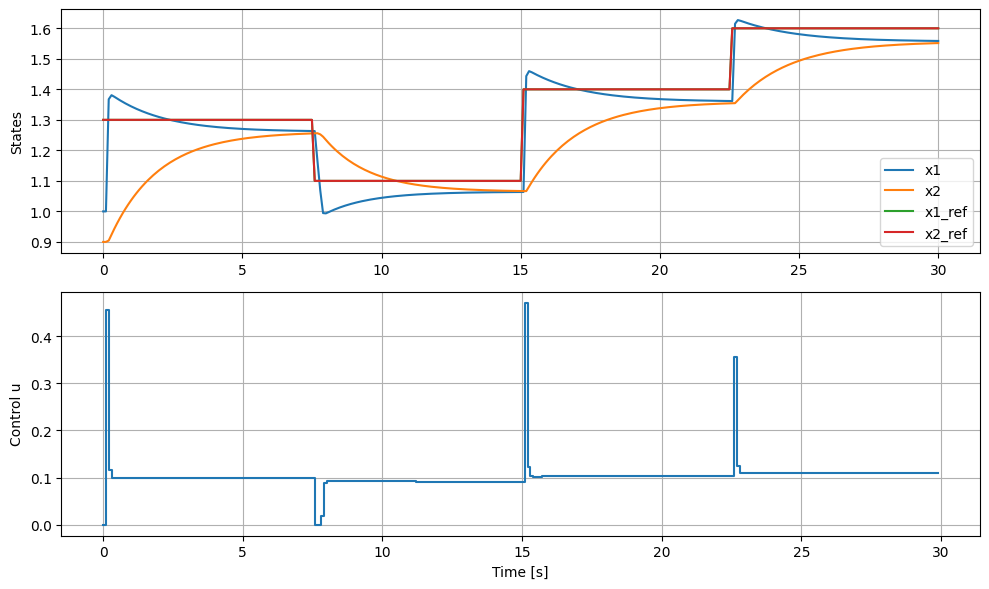

In [79]:

# Define parameters for the cascaded tank system (model dynamics)
k = 1000 # unit conversion
rho = 1000 # density of fluid
g0 = 9.82 # gravity
A1 = 0.1 # area of tank 1
A2  = 0.1 # area of tank 2
a1 = 0.01 # area of tube 1
a2 = 0.01 # area of tube 2

# Define parameters for the cascaded tank system (actual dynamics)
k_actual = 1000 # unit conversion
rho_actual = 1000 # density of fluid
g0_actual = 9.82 # gravity
A1_actual = 0.1 # area of tank 1
A2_actual  = 0.1 # area of tank 2
a1_actual = 0.02 # area of tube 1
a2_actual = 0.02 # area of tube 2

T = 20 # time horizon
N = 60 # number of control intervals
step_horizon = 0.1  # time between steps in seconds
sim_time = 30      # simulation time

# Bounds for control input
u_max = 12
u_min = 0

# Initial state
x1_init = 1.0
x2_init = 0.9

# Reference init (references vary over time)
x1_target = 1.3
x2_target = 1.3


# Symbolic variables
x = ca.MX.sym('x',2) # States
u = ca.MX.sym('u') # Controls
n_states = x.numel()
n_controls = u.numel()

# ODEs (plant model)
eps = 1e-4 # numeric stability 
ode = ca.vertcat(
    k/(rho*A1) * u - a1/A1 * ca.sqrt(2*g0*x[0] + eps), 
    a1/(A1) * ca.sqrt(2*g0*x[0] + eps) - a2/A2 * ca.sqrt(2*g0*x[1] + eps)
              )

ode_actual = ca.vertcat(
    k_actual/(rho_actual*A1_actual) * u - a1_actual/A1_actual * ca.sqrt(2*g0_actual*x[0] + eps), 
    a1_actual/(A1_actual) * ca.sqrt(2*g0_actual*x[0] + eps) - a2_actual/A2_actual * ca.sqrt(2*g0_actual*x[1] + eps)
              )

# A matrix that contains all states over time (+1) where each column is a state vector
X = ca.SX.sym('X', n_states, N + 1)

# A matrix that contains all control inputs over time where each column is a control input
U = ca.SX.sym('U', n_controls, N)

# Coloumn vector for storing initial state and target state
ref = ca.SX.sym('ref', 2*n_states)

# State and control weight matrices used in cost function
w1 = 1.0 # weight on state 1
w2 = 1.0 # weight on state 2
Q = ca.diagcat(w1, w2)

R = 0.1 # a scalar because we only have one control input

# Basically the state update should be next
# State update function
f = ca.Function('f', [x, u], [ode], ['x', 'u'], ['ode'])
f_actual = ca.Function('f', [x, u], [ode_actual], ['x', 'u'], ['ode_actual'])


# Initialize the cost function and cosntraints
cost_fn = 0  # cost function
g = X[:, 0] -ref[:n_states]  # constraints in the equation


# RK method for integration
for k in range(N):
    st = X[:, k]
    con = U[:, k]
    cost_fn = cost_fn \
        + (st - ref[n_states:2*n_states]).T @ Q @ (st - ref[n_states:2*n_states]) \
        + con.T @ R @ con
    st_next = X[:, k+1]
    k1 = f(st, con)
    k2 = f(st + step_horizon/2*k1, con)
    k3 = f(st + step_horizon/2*k2, con)
    k4 = f(st + step_horizon * k3, con)
    st_next_RK4 = st + (step_horizon / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
    g = ca.vertcat(g, st_next - st_next_RK4) # Basically saying X[:, k+1] = runge kutta evaluation

# Final cost (time step N)
cost_fn = cost_fn \
        + (X[:,N] - ref[n_states:2*n_states]).T @ Q @ (X[:,N] - ref[n_states:2*n_states]) \
        + U[:, N-1].T @ R @ U[:, N-1]

# Now we create the solver
# Below does the format where it maps the variables to a single vector (all states all timesteps)
OPT_variables = ca.vertcat(
    X.reshape((-1, 1)),   
    U.reshape((-1, 1))
)

# This creates the NLP problem to be solved
nlp_prob = {
    'f': cost_fn,
    'x': OPT_variables,
    'g': g,
    'p': ref
}

# Parameters for creating the solver
opts = {
    'ipopt': {
        'max_iter': 2000,
        'print_level': 0,
        'sb': 'yes',        # silent mode
        'acceptable_tol': 1e-8,
        'acceptable_obj_change_tol': 1e-6
    },
    'print_time': 0
}

# opts = {
#     'ipopt.print_level': 0,   # <- kills IPOPT spam
#     'ipopt.sb': 'yes',        # silent mode
#     'print_time': 0           # removes timing output
# }


# Create the solver
solver = ca.nlpsol('solver', 'ipopt', nlp_prob, opts)

# Now for the constraints
lbx = ca.DM.zeros((n_states*(N+1) + n_controls*N, 1))
ubx = ca.DM.zeros((n_states*(N+1) + n_controls*N, 1))

lbx[0: n_states*(N+1): n_states] = 0     # x1 lower bound
lbx[1: n_states*(N+1): n_states] = 0     # x2 lower bound

ubx[0: n_states*(N+1): n_states] = ca.inf      # x1 upper bound
ubx[1: n_states*(N+1): n_states] = ca.inf      # x2 upper bound

lbx[n_states*(N+1):] = u_min                  # u lower bound for all u
ubx[n_states*(N+1):] = u_max                  # u upper bound for all u

# Constraint argument
args = {
    'lbg': ca.DM.zeros((n_states*(N+1), 1)),  # constraints lower bound
    'ubg': ca.DM.zeros((n_states*(N+1), 1)),  # constraints upper bound
    'lbx': lbx,
    'ubx': ubx
}

t0 = 0
state_init = ca.DM([x1_init, x2_init])        # initial state
state_target = ca.DM([x1_target, x2_target])  # reference state

# Initialize time
t = ca.DM(t0)

u0 = ca.DM.zeros((n_controls, N))  # initial control
X0 = ca.repmat(state_init, 1, N+1) # initial state
REF = ca.repmat(state_target, 1, N+1) # reference

# Collector variables
mpc_iter = 0
cat_states = DM2Arr(X0)
cat_controls = DM2Arr(u0[:, 0])
cat_ref = DM2Arr(state_target).reshape(-1,1)
times = np.array([[0]])

# The executive function
if __name__ == '__main__':
    main_loop = time()  # return time in sec
    # while (ca.norm_2(state_init - state_target) > 1e-1) and (mpc_iter * step_horizon < sim_time):
    while (mpc_iter * step_horizon < sim_time):
        # init time
        t1 = time()
        t_sim = mpc_iter * step_horizon

        #references
        x1_ref, x2_ref = reference_trajectory(t_sim, sim_time, x1_target, x2_target, change=True)
        state_target = ca.DM([x1_ref, x2_ref])
        cat_ref = np.hstack((
            cat_ref,
            DM2Arr(state_target).reshape(-1,1)
        ))

        args['p'] = ca.vertcat(
            state_init,    # current state
            state_target   # target state
        )
        # Optimization variable current state
        args['x0'] = ca.vertcat(
            ca.reshape(X0, n_states*(N+1), 1),
            ca.reshape(u0, n_controls*N, 1)
        )

        # Instance of the solver
        sol = solver(
            x0=args['x0'],
            lbx=args['lbx'],
            ubx=args['ubx'],
            lbg=args['lbg'],
            ubg=args['ubg'],
            p=args['p']
        )

        u = ca.reshape(sol['x'][n_states * (N + 1):], n_controls, N)
        X0 = ca.reshape(sol['x'][: n_states * (N+1)], n_states, N+1)
        ref = ca.reshape(sol['x'][: n_states * (N+1)], n_states, N+1)

        cat_states = np.dstack((
            cat_states,
            DM2Arr(X0)
        ))

        cat_controls = np.vstack((
            cat_controls,
            DM2Arr(u[:, 0])
        ))

        t = np.vstack((
            t,
            t0
        ))

        # t0, state_init, u0 = shift_timestep(step_horizon, t0, state_init, u, f) # model dynamics
        t0, state_init, u0 = shift_timestep(step_horizon, t0, state_init, u, f_actual) # actual sys dynamics

        # print(X0)
        X0 = ca.horzcat(
            X0[:, 1:],
            ca.reshape(X0[:, -1], -1, 1)
        )

        # xx ...
        t2 = time()
        # print(mpc_iter)
        # print(t2-t1)
        times = np.vstack((
            times,
            t2-t1
        ))

        mpc_iter = mpc_iter + 1
        

    main_loop_time = time()
    ss_error = ca.norm_2(state_init - state_target)

# Number of MPC steps
Tsim = cat_controls.shape[0] - 1
dt = step_horizon

# Extract closed-loop states (first column of X0 at each iteration)
X_log = np.zeros((n_states, Tsim+1))

# Extract reference states
X_ref = np.zeros((n_states, Tsim+1))

for k in range(Tsim+1):
    X_log[:, k] = cat_states[:, 0, k]
    X_ref[:, k] = cat_ref[:, k]

# Extract applied controls
U_log = cat_controls[:Tsim].T   # shape (1, Tsim)

# Plotting
t_x = np.arange(Tsim+1) * dt
t_u = np.arange(Tsim) * dt

plt.figure(figsize=(10,6))

plt.subplot(2,1,1)
plt.plot(t_x, X_log[0,:], label='x1')
plt.plot(t_x, X_log[1,:], label='x2')
plt.plot(t_x, X_ref[0,:], label='x1_ref')
plt.plot(t_x, X_ref[1,:], label='x2_ref')
plt.ylabel('States')
plt.legend()
plt.grid(True)

plt.subplot(2,1,2)
plt.step(t_u, U_log[0,:], where='post')
plt.xlabel('Time [s]')
plt.ylabel('Control u')
plt.grid(True)

plt.tight_layout()
plt.show()

